# Calibration parameter analysis
Loads `calibration_results.json` and explores how each parameter impacts the ABC distance.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RESULTS_PATH = Path("../calibration_mse.json")
EPSILON = 0.1  # must match calibration config

In [2]:
raw = json.loads(RESULTS_PATH.read_text())
print(f"runs: {raw['n_total']}  accepted: {raw['n_accepted']}  rate: {raw['acceptance_rate']:.2%}")

df = pd.json_normalize(raw["runs"])
# rename params.X.Y → X.Y for readability
df.columns = [c.removeprefix("params.") for c in df.columns]

PARAM_COLS = [c for c in df.columns if c not in ("distance", "distance_variance", "n_sims", "verdict")]
print(f"parameters: {PARAM_COLS}")
df.head()

runs: 10  accepted: 0  rate: 0.00%
parameters: ['output_dir', 'rate_function.carrying_capacity']


,distance,distance_variance,n_sims,verdict,output_dir,rate_function.carrying_capacity
0,28.617586,4.089711,20,rejected_early,/tmp/evoseer_abc_1facr_s3,409.582419
1,23.079009,1.927038,28,rejected_early,/tmp/evoseer_abc_8n21zv56,275.551376
2,32.598322,5.694869,20,rejected_early,/tmp/evoseer_abc_asvdi9eb,443.439168
3,23.476486,3.715429,27,rejected_early,/tmp/evoseer_abc_1igjh4oj,378.947212
4,23.058697,0.720582,31,rejected_early,/tmp/evoseer_abc_q8hcgfze,137.670939


## Summary statistics

In [3]:
df[PARAM_COLS + ["distance", "distance_variance"]].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
rate_function.carrying_capacity,10.0,338.5721,121.8409,137.6709,276.7021,391.7015,413.2149,490.2489
distance,10.0,26.0962,4.1098,21.0973,23.1784,23.8135,29.8947,32.5983
distance_variance,10.0,3.9770,2.8699,0.7135,2.0484,3.9026,5.3929,10.3002


In [4]:
df.groupby("verdict")[["distance", "distance_variance"]].agg(["mean", "std", "count"]).round(4)

distance               distance_variance              
                   mean     std count              mean     std count
verdict                                                              
rejected_early  26.0962  4.1098    10             3.977  2.8699    10

## Param vs distance (one scatter per parameter)

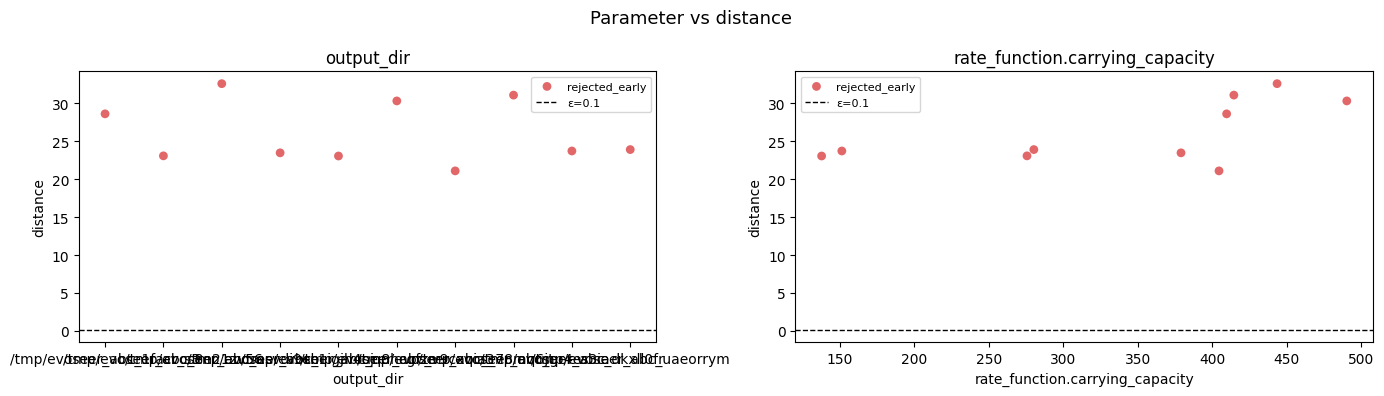

In [5]:
VERDICT_PALETTE = {"accepted": "#2ca02c", "rejected": "#ff7f0e", "rejected_early": "#d62728"}

ncols = 2
nrows = (len(PARAM_COLS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows), squeeze=False)

for ax, param in zip(axes.flat, PARAM_COLS):
    for verdict, grp in df.groupby("verdict"):
        ax.scatter(
            grp[param], grp["distance"],
            c=VERDICT_PALETTE.get(verdict, "gray"),
            label=verdict, alpha=0.7, s=40, edgecolors="none",
        )
    ax.axhline(EPSILON, color="black", linestyle="--", linewidth=1, label=f"ε={EPSILON}")
    ax.set_xlabel(param)
    ax.set_ylabel("distance")
    ax.set_title(param)
    ax.legend(fontsize=8)

# hide unused axes
for ax in axes.flat[len(PARAM_COLS):]:
    ax.set_visible(False)

plt.suptitle("Parameter vs distance", fontsize=13)
plt.tight_layout()
plt.show()

## Distance variance vs distance

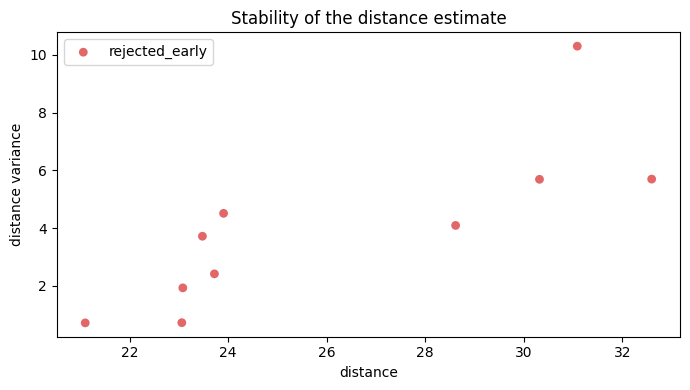

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for verdict, grp in df.groupby("verdict"):
    ax.scatter(
        grp["distance"], grp["distance_variance"],
        c=VERDICT_PALETTE.get(verdict, "gray"),
        label=verdict, alpha=0.7, s=40, edgecolors="none",
    )
ax.set_xlabel("distance")
ax.set_ylabel("distance variance")
ax.set_title("Stability of the distance estimate")
ax.legend()
plt.tight_layout()
plt.show()

## Pair plot — parameter space coloured by distance

TypeError: The x variable is categorical, but one of ['numeric', 'datetime'] is required

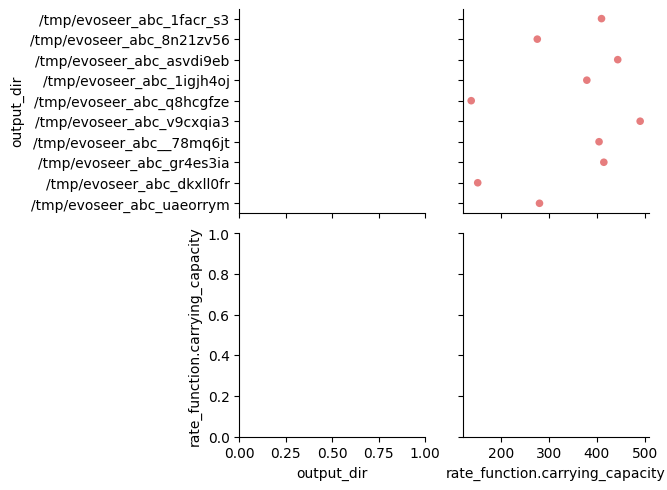

In [8]:
plot_df = df[PARAM_COLS + ["distance", "verdict"]].copy()

g = sns.PairGrid(plot_df, vars=PARAM_COLS, hue="verdict", palette=VERDICT_PALETTE)
g.map_upper(sns.scatterplot, alpha=0.6, s=30, edgecolors="none")
g.map_lower(sns.kdeplot, fill=True, alpha=0.3)
g.map_diag(sns.kdeplot, fill=True)
g.add_legend()
g.figure.suptitle("Parameter pair plot (verdict hue)", y=1.01, fontsize=13)
plt.show()

## Accepted runs — parameter distribution vs prior

In [9]:
accepted = df[df["verdict"] == "accepted"]

if accepted.empty:
    print("No accepted runs — lower ε or run more samples.")
else:
    ncols = 2
    nrows = (len(PARAM_COLS) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows), squeeze=False)

    for ax, param in zip(axes.flat, PARAM_COLS):
        sns.kdeplot(df[param], ax=ax, label="all", fill=True, alpha=0.3, color="steelblue")
        sns.kdeplot(accepted[param], ax=ax, label="accepted", fill=True, alpha=0.5, color="#2ca02c")
        ax.set_xlabel(param)
        ax.set_title(param)
        ax.legend()

    for ax in axes.flat[len(PARAM_COLS):]:
        ax.set_visible(False)

    plt.suptitle("Posterior (accepted) vs prior (all runs)", fontsize=13)
    plt.tight_layout()
    plt.show()

No accepted runs — lower ε or run more samples.


## Clone size distributions per run

In [10]:
def load_clone_sizes(output_dir: str) -> list[float]:
    """Load all non-wt final clone sizes from simulation JSON files in output_dir."""
    p = Path(output_dir)
    if not p.exists():
        return []
    sizes = []
    for f in sorted(p.glob("simulation.*.evoseer.json")):
        data = json.loads(f.read_text())
        sizes.extend(
            float(node["final_size"])
            for node in data["clone_tree"]["nodes"]
            if node["id"] != "wt" and node["final_size"] > 0
        )
    return sizes


# Build a long-form DataFrame: one row per clone, with run metadata
records = []
for i, run in enumerate(raw["runs"]):
    output_dir = run.get("output_dir", "")
    sizes = load_clone_sizes(output_dir)
    for s in sizes:
        records.append({
            "run": i,
            "verdict": run["verdict"],
            "distance": run["distance"],
            "clone_size": s,
            **{k.removeprefix("params."): v for k, v in pd.json_normalize([run["params"]]).iloc[0].items()},
        })

clone_df = pd.DataFrame(records)
print(f"{len(clone_df)} clones across {clone_df['run'].nunique()} runs with simulation output")
clone_df.head()

397 clones across 10 runs with simulation output


,run,verdict,distance,clone_size,rate_function.carrying_capacity
0,0,rejected_early,28.617586,3.0,409.582419
1,0,rejected_early,28.617586,32.0,409.582419
2,0,rejected_early,28.617586,49.0,409.582419
3,0,rejected_early,28.617586,18.0,409.582419
4,0,rejected_early,28.617586,27.0,409.582419


In [12]:
clone_df

,run,verdict,distance,clone_size,rate_function.carrying_capacity,run_label
0,0,rejected_early,28.617586,3.0,409.582419,run 0\nd=28.618
1,0,rejected_early,28.617586,32.0,409.582419,run 0\nd=28.618
2,0,rejected_early,28.617586,49.0,409.582419,run 0\nd=28.618
3,0,rejected_early,28.617586,18.0,409.582419,run 0\nd=28.618
4,0,rejected_early,28.617586,27.0,409.582419,run 0\nd=28.618
...,...,...,...,...,...,...
392,9,rejected_early,23.906248,20.0,280.154375,run 9\nd=23.906
393,9,rejected_early,23.906248,24.0,280.154375,run 9\nd=23.906
394,9,rejected_early,23.906248,35.0,280.154375,run 9\nd=23.906
395,9,rejected_early,23.906248,34.0,280.154375,run 9\nd=23.906


/tmp/ipykernel_1738420/2968878527.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


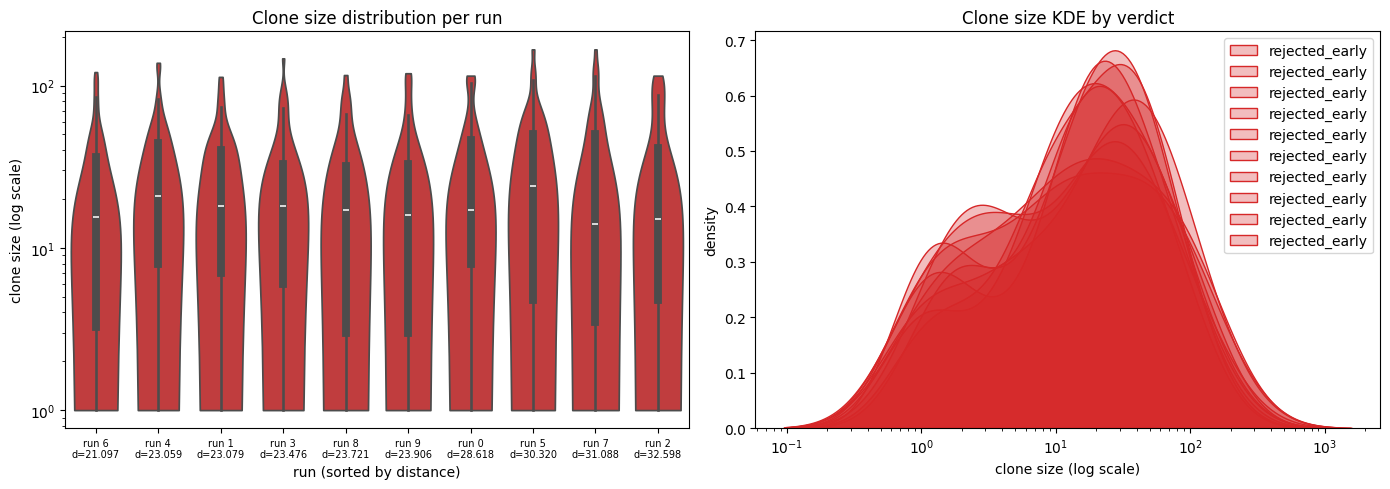

In [13]:
if clone_df.empty:
    print("No simulation output found — re-run calibration with the new output_dir support.")
else:
    # Sort runs by distance so the x-axis goes from best to worst
    run_order = (
        clone_df.groupby("run")["distance"].first()
        .sort_values()
        .index.tolist()
    )
    run_labels = {r: f"run {r}\nd={clone_df[clone_df['run']==r]['distance'].iloc[0]:.3f}" for r in run_order}
    clone_df["run_label"] = clone_df["run"].map(run_labels)
    ordered_labels = [run_labels[r] for r in run_order]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Violin per run, ordered by distance
    ax = axes[0]
    palette = {run_labels[r]: VERDICT_PALETTE.get(clone_df[clone_df["run"]==r]["verdict"].iloc[0], "gray") for r in run_order}
    sns.violinplot(
        data=clone_df, x="run_label", y="clone_size",
        order=ordered_labels, palette=palette,
        inner="box", cut=0, ax=ax,
    )
    ax.set_yscale("log")
    ax.set_xlabel("run (sorted by distance)")
    ax.set_ylabel("clone size (log scale)")
    ax.set_title("Clone size distribution per run")
    ax.tick_params(axis="x", labelsize=7)

    # KDE overlay: accepted vs rejected
    ax = axes[1]
    for run_label, grp in clone_df.groupby("run_label"):
        sns.kdeplot(
            grp["clone_size"], ax=ax,
            label=verdict, fill=True, alpha=0.3,
            color=VERDICT_PALETTE.get(verdict, "gray"), log_scale=True,
        )
    ax.set_xlabel("clone size (log scale)")
    ax.set_ylabel("density")
    ax.set_title("Clone size KDE by verdict")
    ax.legend()

    plt.tight_layout()
    plt.show()